In [10]:
import math
import bisect

class KLLSketch:
    """
    A minimal, demonstrative implementation of the KLL Sketch
    for scalar data. For large datasets, consider more robust
    or optimized versions.
    """
    def __init__(self, capacity=200):
        self.capacity = capacity
        self.levels = [[]]  # Each level is a list of items
        self.n = 0          # Total count of data items

    def update(self, value):
        """
        Update the sketch with a new scalar value (streaming).
        """
        self.n += 1
        self.levels[0].append(value)

        # If the first level is at capacity, we need to compress
        if len(self.levels[0]) > self.capacity:
            self._compress_level(0)

    def _compress_level(self, level_idx):
        """
        Compress one level of the KLL sketch, pushing
        roughly half of the items up to the next level.
        """
        level = self.levels[level_idx]
        level.sort()
        # Take every other item to promote (downsample by 2).
        promoted = level[::2]
        # The next level might not exist yet
        if level_idx + 1 == len(self.levels):
            self.levels.append([])
        self.levels[level_idx + 1].extend(promoted)
        # Reset this level
        self.levels[level_idx] = []
        # Potentially keep compressing upward
        if len(self.levels[level_idx + 1]) > self.capacity:
            self._compress_level(level_idx + 1)

    def _sorted_values(self):
        """
        Return all values in the sketch as a single sorted list.
        """
        merged = []
        for i, lvl in enumerate(self.levels):
            merged.extend(lvl)
        merged.sort()
        return merged

    def rank(self, value):
        """
        Return the number of elements in the distribution less than
        or equal to 'value'.  (i.e., the rank).
        """
        merged = self._sorted_values()
        # Use bisect to get how many are <= value
        return bisect.bisect_right(merged, value)

    def cdf(self, value):
        """
        Return the empirical CDF at 'value':
            CDF(value) = rank(value) / total_count
        """
        if self.n == 0:
            return 0.0
        return self.rank(value) / float(self.n)


class KLLDimensionReducer:
    """
    Dimension-wise KLL aggregator. We fit once using the baseline embeddings.
    Then transform new embeddings from dimension D down to 2D.
    """
    def __init__(self, capacity=200):
        self.capacity = capacity
        self.sketches = []
        self.fitted = False

    def fit(self, baseline_embs):
        """
        baseline_embs: (num_samples, D) array of baseline embeddings.
        We build one KLL sketch per dimension.
        """
        num_dims = baseline_embs.shape[1]
        self.sketches = [KLLSketch(capacity=self.capacity) for _ in range(num_dims)]

        # Update each dimension's KLL with the baseline data
        for row in baseline_embs:
            for d in range(num_dims):
                self.sketches[d].update(row[d])

        self.fitted = True

    def transform_one(self, emb):
        """
        Convert a single embedding (D-dimensional) to 2D
        by taking the rank-based percentile in dimension 0 and dimension 1.
        """
        if not self.fitted:
            raise ValueError("KLLDimensionReducer not fitted yet!")

        # Get dimension 0's rank percentile
        cdf_0 = self.sketches[0].cdf(emb[0])
        # Dimension 1's rank percentile
        cdf_1 = self.sketches[1].cdf(emb[1])

        return np.array([cdf_0, cdf_1])

    def transform_batch(self, embs):
        """
        For a batch of embeddings: (batch_size, D),
        return (batch_size, 2).
        """
        return np.vstack([self.transform_one(e) for e in embs])

In [11]:
import os
import random
import torch
import time
import numpy as np

from matplotlib import pyplot as plt
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from collections import defaultdict
import math

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "output_dir": "results_multidataset",
    "num_seeds": 1,  # Number of repeated trials for error bars
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# 1) Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 2) Vector/Feature-Space Distance Functions
###############################################################################
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)

DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),  # example p=3
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}

###############################################################################
# 3) EmbeddingTracker for Mahalanobis or the simpler distances
###############################################################################
class EmbeddingTracker:
    """
    A tracker that maintains:
    - An exponential-moving-average (EMA) of the embedding mean
    - An exponential-moving-average covariance (for Mahalanobis)
    - A selected distance metric: from one of the DISTANCE_FUNCTIONS
    """
    def __init__(self, embedding_dim, alpha=0.01, distance_name="mahalanobis"):
        self.alpha = alpha
        self.distance_name = distance_name

        # For all trackers, keep track of the mean.
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

        # Mahalanobis-specific
        self.cov = np.eye(embedding_dim)

    def update(self, embedding):
        """Update the running mean (and covariance, if Mahalanobis) and cache the inverse covariance periodically."""
        update_interval = 10  # Update the cached inverse every 10 updates

        if self.count == 0:
            self.mean = embedding
            if self.distance_name == "mahalanobis":
                self.cov = np.eye(len(embedding))
                self.cov_inv = np.eye(len(embedding))  # initialize cached inverse covariance
        else:
            # Update the exponential moving average for the mean.
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

            if self.distance_name == "mahalanobis":
                diff = embedding - self.mean
                # Update the covariance using an exponential moving average.
                self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
                # Only update the inverse covariance periodically.
                if self.count % update_interval == 0:
                    try:
                        self.cov_inv = np.linalg.inv(self.cov)
                    except np.linalg.LinAlgError:
                        self.cov_inv = np.linalg.pinv(self.cov)
        self.count += 1


    def compute_distance(self, embedding, use_diagonal=True):
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            if use_diagonal:
                # Avoid division by zero with a small constant
                diag = np.diag(self.cov) + 1e-12
                cov_inv_diag = 1.0 / diag
                return np.sqrt(np.sum(diff**2 * cov_inv_diag))
            else:
                cov_inv = np.linalg.pinv(self.cov)
                return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)


def collect_data_single_seed(seed):
    set_seed(seed)

    # Detect device, etc.
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device)
            model.eval()

            # Precompute baseline embeddings in batches.
            baseline_emb_batches = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_emb_batches.append(emb_b)
            baseline_embs = np.concatenate(baseline_emb_batches, axis=0)

            # Compute the overall baseline mean
            baseline_mean = baseline_embs.mean(axis=0)
            key = (dataset_name, model_name)

            # ### KLL Integration ###
            # Fit a KLL-based 2D reducer on baseline embeddings (once per model/dataset).
            kll_reducer = KLLDimensionReducer(capacity=200)
            kll_reducer.fit(baseline_embs)  # baseline_embs is shape (num_baseline, D)

            # We also produce a "baseline_mean_2D" for our KLL-based tracking
            baseline_mean_2D = kll_reducer.transform_one(baseline_mean)

            # Precompute drifted texts once per drift_strength.
            drifted_texts_by_strength = {
                drift_strength: introduce_gradual_drift(
                    drift_texts, fraction_shuffle=drift_strength
                )
                for drift_strength in args["drift_strengths"]
            }

            # For each distance metric and drift strength, run the test.
            all_distance_names = ["mahalanobis"] + list(DISTANCE_FUNCTIONS.keys())

            for distance_name in all_distance_names:
                for drift_strength in args["drift_strengths"]:
                    test_texts = baseline_texts + drifted_texts_by_strength[drift_strength]

                    # ### NO PCA / Original dimension tracking:
                    embedding_dim_no_pca = baseline_embs.shape[1]
                    tracker_no_pca = EmbeddingTracker(
                        embedding_dim_no_pca,
                        alpha=0.01,
                        distance_name=distance_name
                    )
                    tracker_no_pca.update(baseline_mean)

                    distance_scores_no_pca = []
                    time_overhead_no_pca = []
                    start_time_no_pca = time.time()

                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        overhead_start = time.time()
                        dist = tracker_no_pca.compute_distance(mean_emb)
                        overhead_end = time.time()
                        distance_scores_no_pca.append(dist)
                        time_overhead_no_pca.append(overhead_end - overhead_start)
                        tracker_no_pca.update(mean_emb)

                    end_time_no_pca = time.time()
                    final_dist_no_pca = distance_scores_no_pca[-1] if distance_scores_no_pca else 0.0
                    avg_overhead_no_pca = np.mean(time_overhead_no_pca)
                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "pca": False,
                        "final_similarity": final_dist_no_pca,
                        "time_taken": end_time_no_pca - start_time_no_pca,
                        "avg_overhead": avg_overhead_no_pca,
                        "seed": seed,
                    })

                    # ### KLL-based tracking in 2D:
                    # We'll create a separate tracker that handles 2D embeddings only.
                    tracker_kll = EmbeddingTracker(
                        embedding_dim=2,
                        alpha=0.01,
                        distance_name=distance_name
                    )
                    # Initialize it with the 2D baseline mean
                    tracker_kll.update(baseline_mean_2D)

                    distance_scores_kll = []
                    time_overhead_kll = []
                    start_time_kll = time.time()

                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        # Convert to 2D
                        emb_2d = kll_reducer.transform_batch(emb)
                        mean_emb_2d = emb_2d.mean(axis=0)   # shape (2,)

                        overhead_start = time.time()
                        dist_kll = tracker_kll.compute_distance(mean_emb_2d)
                        overhead_end = time.time()
                        distance_scores_kll.append(dist_kll)
                        time_overhead_kll.append(overhead_end - overhead_start)

                        # Update tracker with new 2D point
                        tracker_kll.update(mean_emb_2d)

                    end_time_kll = time.time()
                    final_dist_kll = distance_scores_kll[-1] if distance_scores_kll else 0.0
                    avg_overhead_kll = np.mean(time_overhead_kll)

                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "pca": "kll_2d",
                        "final_similarity": final_dist_kll,
                        "time_taken": end_time_kll - start_time_kll,
                        "avg_overhead": avg_overhead_kll,
                        "seed": seed,
                    })

    return results



###############################################################################
# 5) Collect Data Across Multiple Seeds
###############################################################################
def collect_data_multiple_seeds():
    all_results = defaultdict(list)

    for seed in range(args["num_seeds"]):
        seed_results = collect_data_single_seed(seed)

        # Merge the per-seed results into the master
        for key, records in seed_results.items():
            all_results[key].extend(records)

    print("\nAll seeds complete!")
    return all_results

###############################################################################
# Run the Multi-Seed Experiments
###############################################################################
all_results = collect_data_multiple_seeds()

[Seed=0] Using device: mps
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---



All seeds complete!


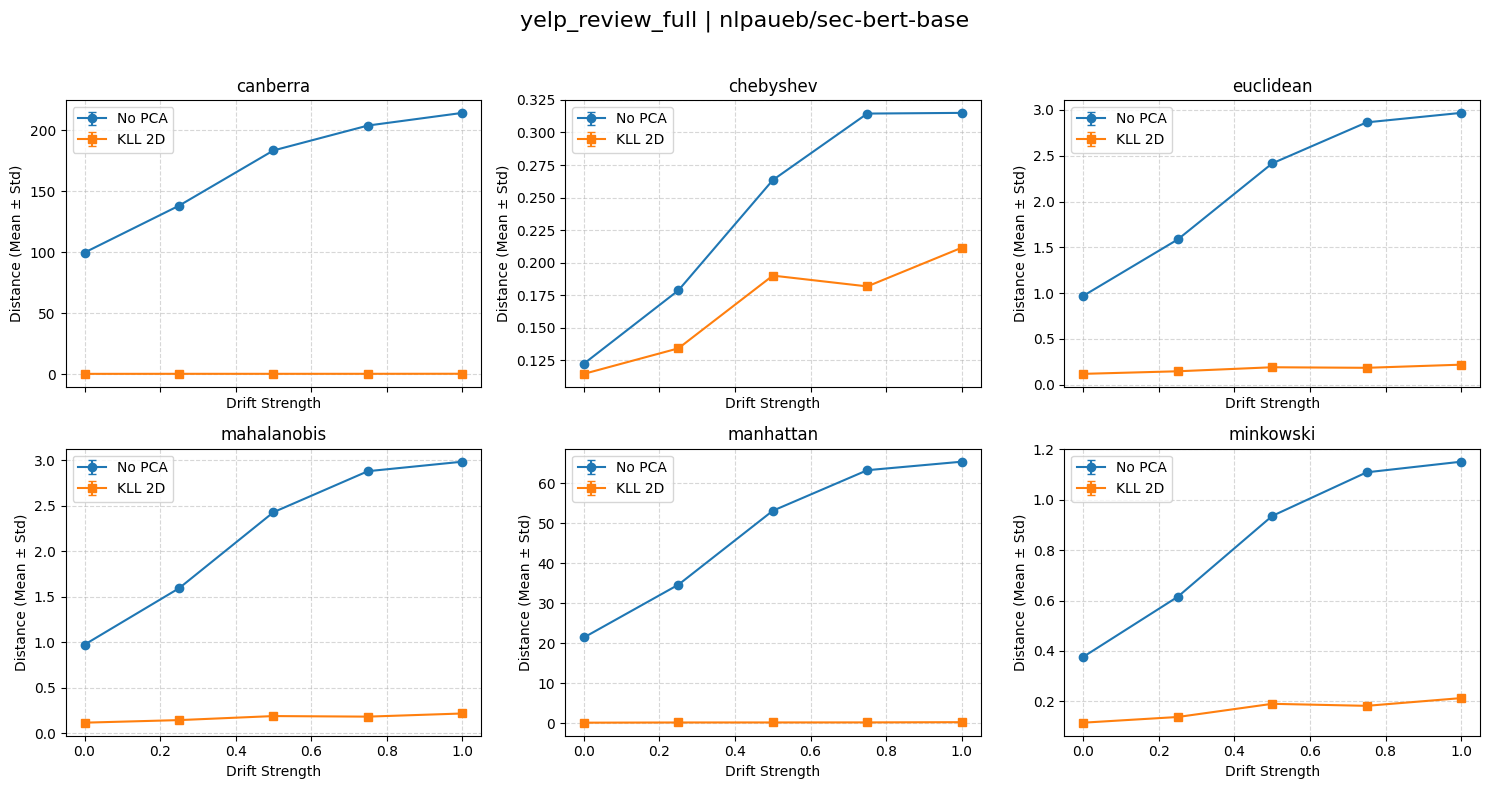

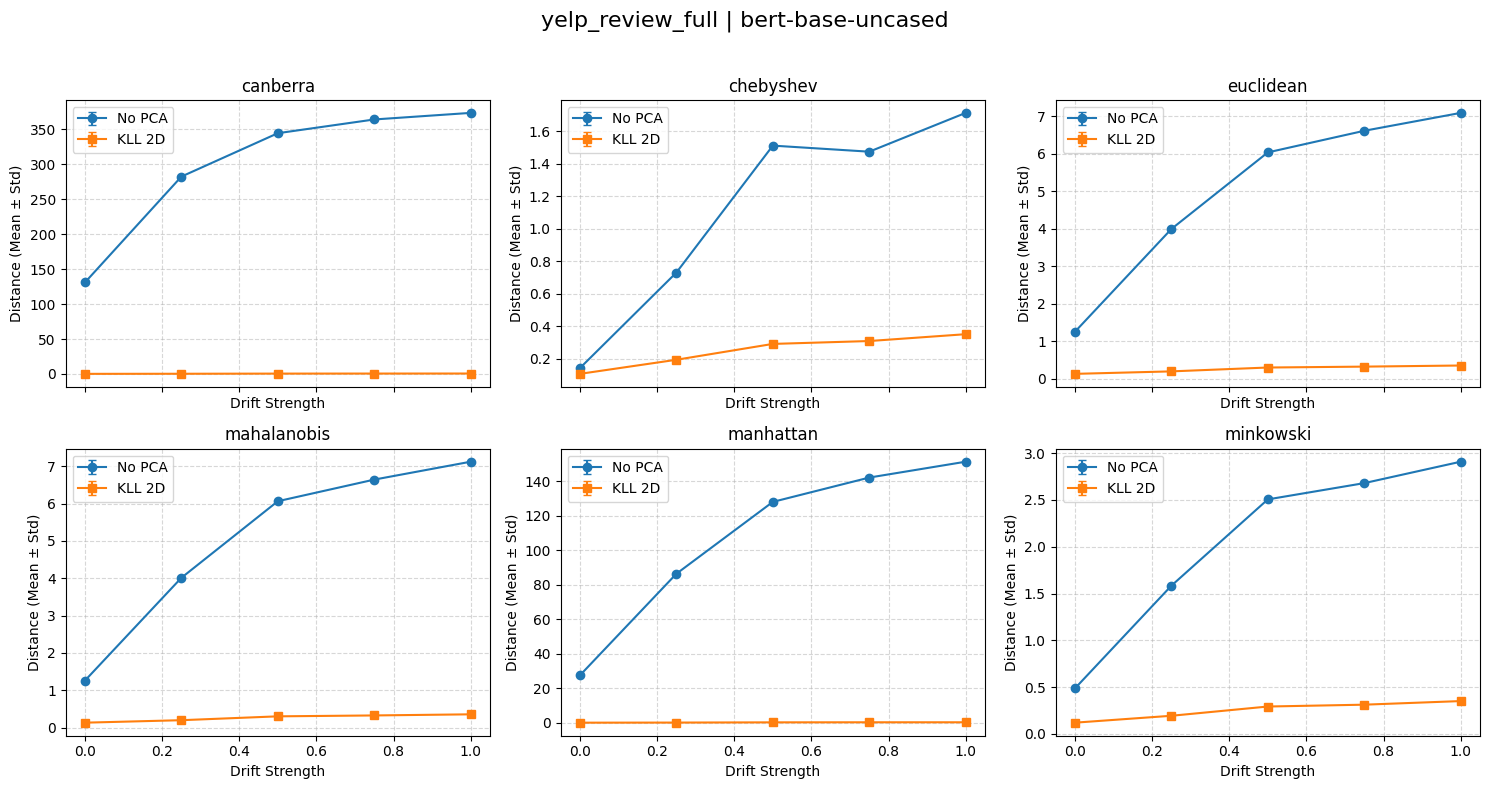

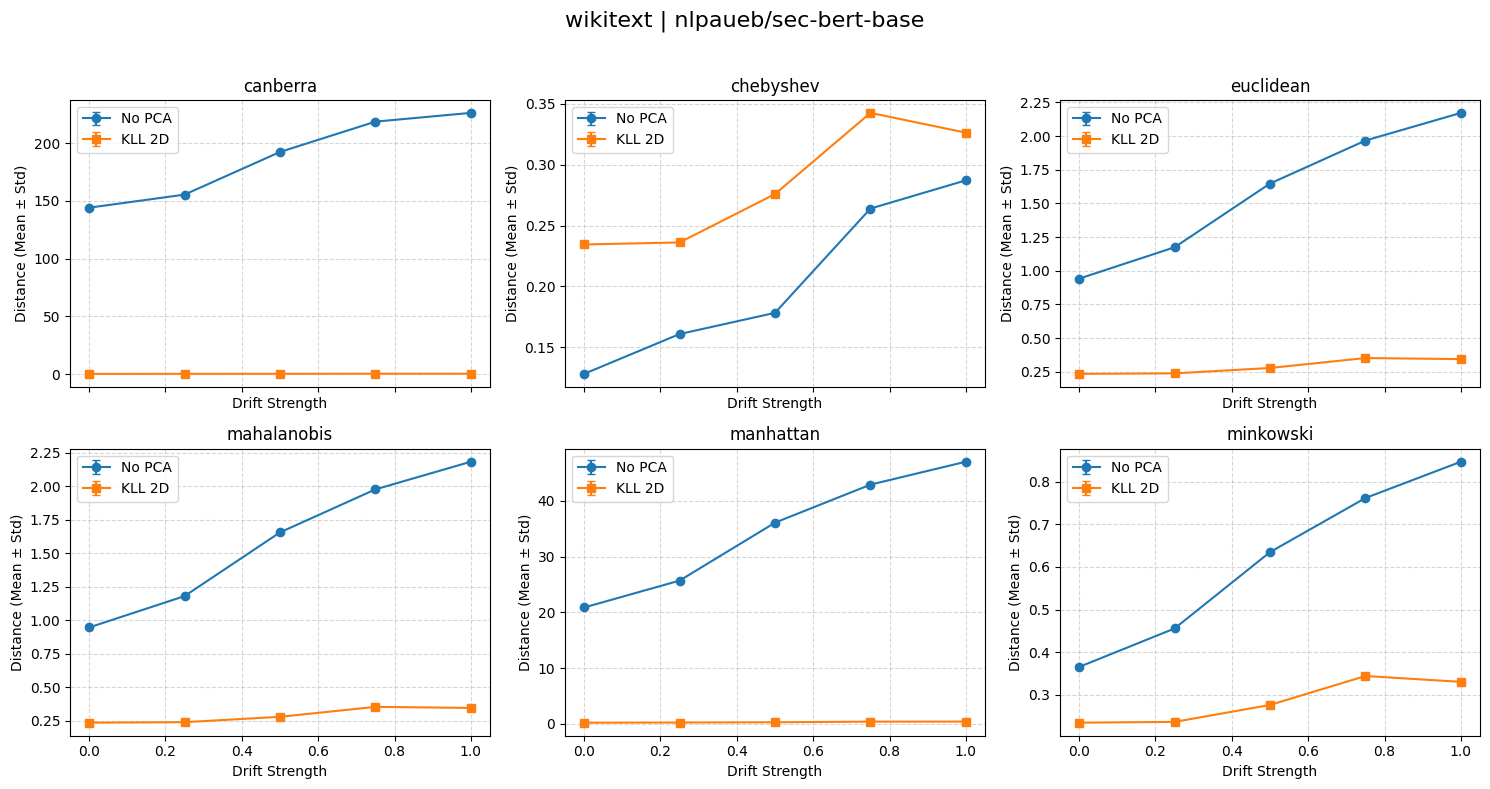

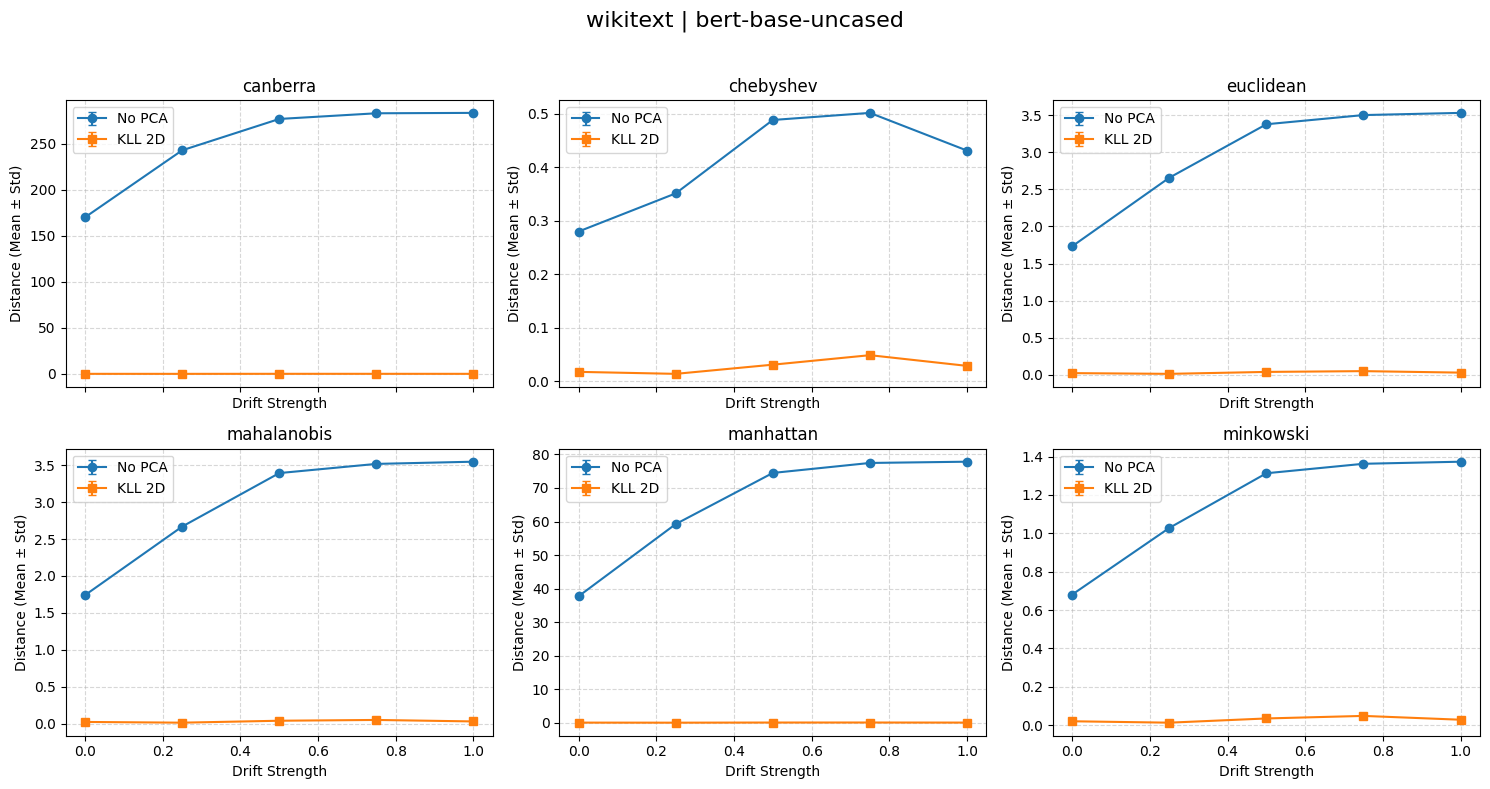

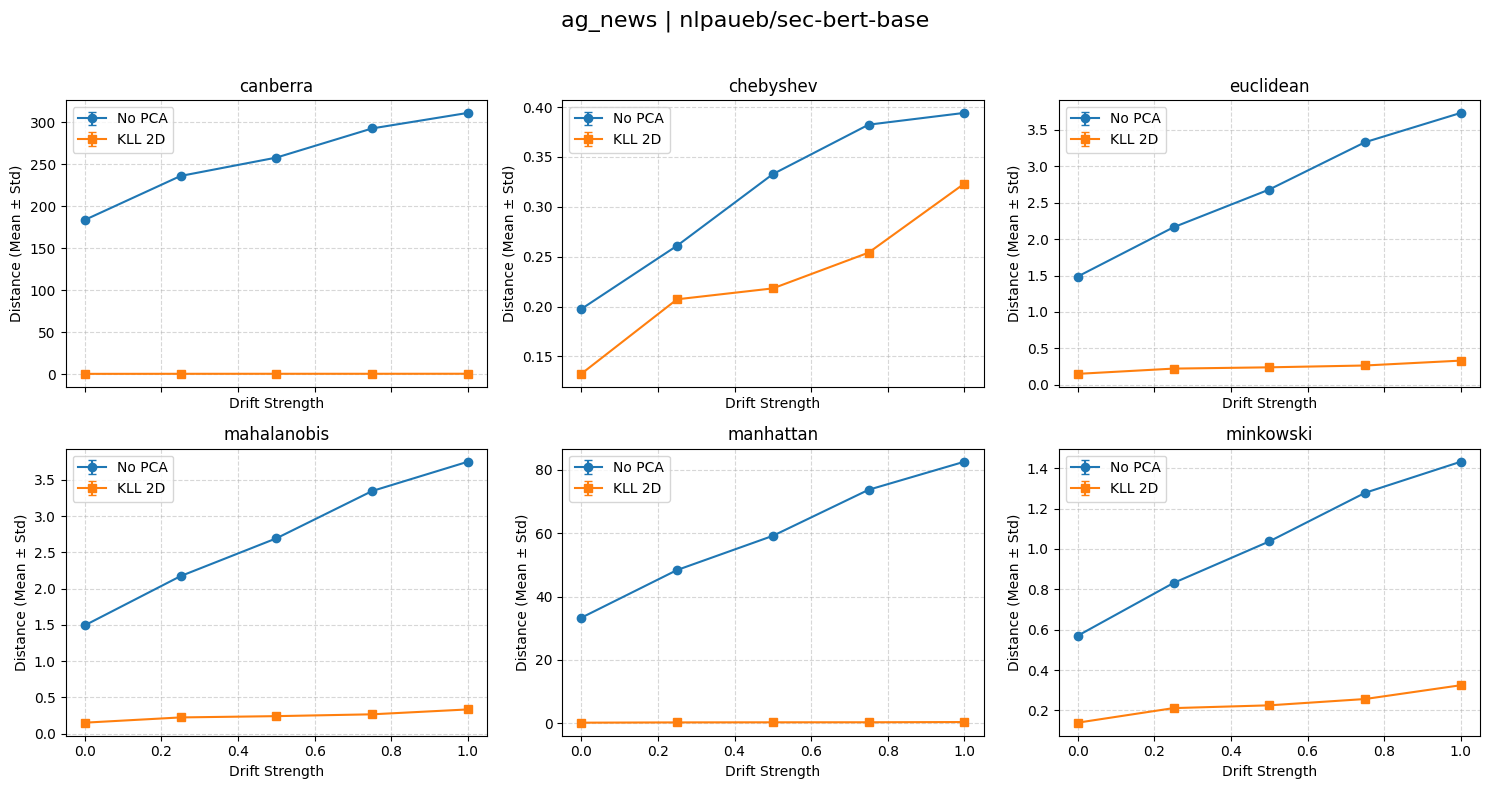

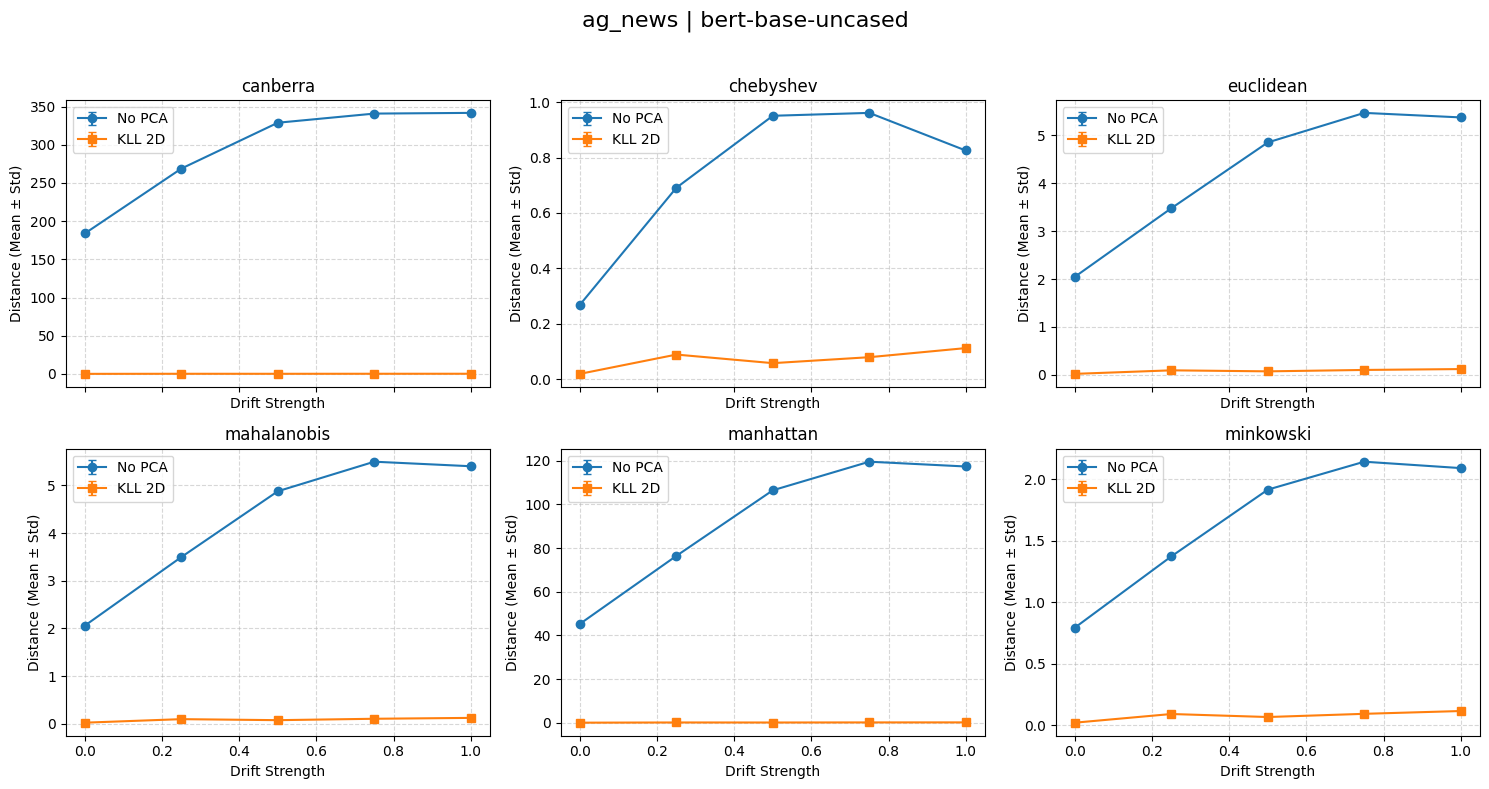

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from collections import defaultdict

def plot_distance_with_error_bars(all_results):
    """
    Plot error bars for No PCA vs. KLL 2D distance metrics across drift strengths.
    """
    # Aggregate: key = (dataset_name, model_name, distance_name, drift_strength, pca_flag)
    aggregator = defaultdict(list)
    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            dist_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            final_dist = r["final_similarity"]
            pca_flag = r["pca"]  # This will distinguish No PCA vs. KLL

            key = (dataset_name, model_name, dist_name, drift_strength, pca_flag)
            aggregator[key].append(final_dist)

    # Compute mean and std for each key.
    aggregated_data = []
    for key, dist_values in aggregator.items():
        dataset_name, model_name, dist_name, drift_strength, pca_flag = key
        mean_val = np.mean(dist_values)
        std_val = np.std(dist_values)
        aggregated_data.append({
            "dataset_name": dataset_name,
            "model_name": model_name,
            "distance_name": dist_name,
            "drift_strength": drift_strength,
            "pca_flag": pca_flag,
            "mean_val": mean_val,
            "std_val": std_val
        })

    # Group the aggregated data by (dataset_name, model_name) for plotting.
    grouped = defaultdict(list)
    for row in aggregated_data:
        key = (row["dataset_name"], row["model_name"])
        grouped[key].append(row)

    for (dataset_name, model_name), rows in grouped.items():
        # Gather all unique distance names.
        dist_names = sorted(set(r["distance_name"] for r in rows))
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            # Filter data for the given distance metric.
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]

            # Separate No PCA and KLL results
            dist_rows_no_pca = sorted([r for r in dist_rows if r["pca_flag"] == False], key=lambda x: x["drift_strength"])
            dist_rows_kll = sorted([r for r in dist_rows if r["pca_flag"] == "kll_2d"], key=lambda x: x["drift_strength"])

            x_no_pca = [r["drift_strength"] for r in dist_rows_no_pca]
            y_no_pca = [r["mean_val"] for r in dist_rows_no_pca]
            e_no_pca = [r["std_val"] for r in dist_rows_no_pca]

            x_kll = [r["drift_strength"] for r in dist_rows_kll]
            y_kll = [r["mean_val"] for r in dist_rows_kll]
            e_kll = [r["std_val"] for r in dist_rows_kll]

            # Plot error bars
            ax.errorbar(x_no_pca, y_no_pca, yerr=e_no_pca, fmt='-o', capsize=3, label="No PCA")
            ax.errorbar(x_kll, y_kll, yerr=e_kll, fmt='-s', capsize=3, label="KLL 2D")
            ax.set_title(dist_name)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance (Mean ± Std)")
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend()

        # Hide any unused subplots.
        for j in range(i+1, n_rows*n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

def plot_overhead_bar_aggregated(summary_overhead):
    """
    Create a grouped bar chart of overhead for No PCA vs. KLL, aggregated across all
    datasets, models, and drift strengths, using a log scale.
    """

    # Aggregate across Dataset, Model, and Drift Strength
    grouped = (
        summary_overhead
        .groupby(["distance_name", "pca"])
        .agg(
            overhead_mean=("mean_overhead", "mean"),
            overhead_std=("mean_overhead", "std"),
        )
        .reset_index()
    )

    # Prepare data for grouped bar chart
    distance_names = sorted(grouped["distance_name"].unique())
    x_positions = np.arange(len(distance_names))
    bar_width = 0.4

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, pca_flag in enumerate([False, "kll_2d"]):
        subset = grouped[grouped["pca"] == pca_flag]
        label = "No PCA" if pca_flag == False else "KLL 2D"
        ax.bar(
            x_positions + i * bar_width,
            subset["overhead_mean"],
            yerr=subset["overhead_std"],
            width=bar_width,
            capsize=5,
            alpha=0.7,
            label=label
        )

    ax.set_yscale("log")
    ax.set_xticks(x_positions + bar_width / 2)
    ax.set_xticklabels(distance_names, rotation=45, ha="right")
    ax.set_title("Average Overhead by Distance Metric (Log Scale)")
    ax.set_xlabel("Distance Metric")
    ax.set_ylabel("Overhead (seconds, log scale)")
    ax.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

# Assuming `all_results` and `summary_overhead` are provided
plot_distance_with_error_bars(all_results)

  distance_name  drift_strength     pca  final_similarity  time_taken  \
0   mahalanobis            0.00   False          0.975391    0.565775   
1   mahalanobis            0.00  kll_2d          0.118775    0.556449   
2   mahalanobis            0.25   False          1.593978    0.561396   
3   mahalanobis            0.25  kll_2d          0.147007    0.560572   
4   mahalanobis            0.50   False          2.428926    0.556621   

   avg_overhead  seed           Dataset                  Model  
0      0.000045     0  yelp_review_full  nlpaueb/sec-bert-base  
1      0.000021     0  yelp_review_full  nlpaueb/sec-bert-base  
2      0.000034     0  yelp_review_full  nlpaueb/sec-bert-base  
3      0.000030     0  yelp_review_full  nlpaueb/sec-bert-base  
4      0.000044     0  yelp_review_full  nlpaueb/sec-bert-base  
   Dataset              Model distance_name  drift_strength     pca  \
0  ag_news  bert-base-uncased      canberra            0.00   False   
1  ag_news  bert-base-uncased

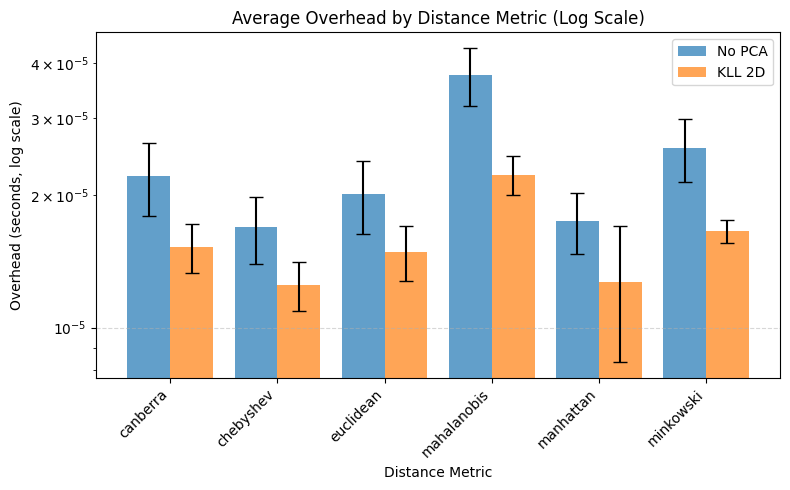

In [17]:
import pandas as pd

# Flatten the all_results dictionary into a list of records
rows = []
for (dataset, model), records in all_results.items():
    for record in records:
        record['Dataset'] = dataset
        record['Model'] = model
        # Ensure 'pca' column exists
        record['pca'] = record.get('pca', 'No PCA')
        rows.append(record)

df = pd.DataFrame(rows)

# Check the structure of df before proceeding
print(df.head())  # Debugging: Inspect DataFrame structure

# Compute summary statistics.
summary_overhead = df.groupby(["Dataset", "Model", "distance_name", "drift_strength", "pca"]).agg(
    mean_overhead=("avg_overhead", "mean"),
    std_overhead=("avg_overhead", "std")
).reset_index()

# Check if "pca" exists in summary_overhead
print(summary_overhead.head())  # Debugging: Verify presence of 'pca' column

# Plot using log scale and save results to CSV.
output_csv_path = os.path.join("../data-analysis/data-test", "summary_overhead_vector-distance.csv")

# Run the plotting function
plot_overhead_bar_aggregated(summary_overhead)
